# Estructura de los Datos

In [5]:
import sys
from pathlib import Path

# Resuelve el problema de las ubicaciones de los scripts
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config
from src.data import DataRepository
from src.preprocessing import PreprocessingPipeline
from src.eda import StatisticsAnalyzer, OutlierDetector

# Tema visual por defecto del proyecto.
sns.set_theme(style=config.SEABORN_THEME, palette=config.PLOT_PALETTE)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 200)

El dataset contiene 413,952 registros que abarcan desde enero de 2015 hasta diciembre de 2025 (11 años). Los datos están organizados a nivel estatal con granularidad mensual (32 entidades × 40+ tipos de delito × 132 meses), lo que nos permite hacer análisis longitudinales de la evolución del delito en cada estado.

In [6]:
repo = DataRepository()
dataframe = repo.load()
repo.metadata.to_dict()

{'source': 'Secretariado Ejecutivo del Sistema Nacional de Seguridad Pública (SESNP), mediante datos.gob.mx',
 'title': 'Incidencia Delictiva Estatal',
 'extraction_date': '2026-06-01',
 'path': '/Users/wallsified/Documents/UNAM/2026-2/Almacenes y Mineria de Datos/proyecto-final-aymdd/data/INM_estatal_dic25.csv',
 'url': 'https://www.datos.gob.mx/dataset/incidencia_delictiva/resource/d9b2792a-33a2-4ea8-8527-210d9e99de5e',
 'encoding': 'utf-8'}

Veamos el diccionario de datos del dataset original. La descripción de las columnas está escrita tal cual como vienen de su fuente.

In [7]:
repo.dictionary()

,columna,tipo,descripcion
0,anio,int64,Año de registro de las averiguaciones previas y/o carpetas de investigación.
1,clave_ent,int64,"Clave de la entidad, según el Marco Geoestadístico Nacional (MGN) del Instituto Nacional de Geografía y Estadística (INEGI)."
2,entidad,str,Entidad federativa de registro de las averiguaciones previas y/o carpetas de investigación.
3,bien_juridico_afectado,str,"Primera clasificación de los delitos en las averiguaciones previas y/o carpetas de investigación. (Patrimonio, vida, libertad, etc.)"
4,tipo_delito,str,"Segunda clasificación de los delitos. (Falsedad, Lesiones, Robo, etc.)"
5,subtipo_delito,str,"Tercera clasificación de los delitos. Subcategorías específicas de cada tipo de delito. (Lesiones dolosas, etc. Puede ser repetido con la anterior)"
6,modalidad,str,"Cuarta clasificación de los delitos. Forma en la que se comete el delito. (Con violencia, sin violencia, etc.)"
7,mes,str,Mes de registro de las averiguaciones previas y/o carpetas de investigación.
8,fecha,str,Fecha de registro de las averiguaciones previas y/o carpetas de investigación.
9,incidencia_delictiva,int64,Incidencia delictiva del Fuero Común (Número absoluto de presuntos delitos registrados)


# Análisis Exploratorio de Datos

## Calidad de los Datos

Haremos lo siguiente con el dataset original: 
- Borraremos las columnas año y mes para poder trabajar únicamente con fecha. Posteriormente, ésta última pasará a ser de tipo `datatime`.
- 'entidad_federativa' es un duplicado de 'entidad', por lo que borramos ésta columna.
- 'clave_entidad' no nos es de útilidad al ya tener el nombre de las entendidades, por lo que borramos ésta columna.
- Analizamos el dataset en busca de duplicados y valores nulos.
- Consideraremos que una entrada es inválida si tiene valores NaN en 'incidencia_delictiva', 'fecha' y 'entendidad'. Una vez detectadas, serán eliminadas.
- Por revisión manual, vemos que algunos estados tienen su nombre completo, como 'Veracruz de Ignacio de la Llave'. Acortaremos el nombre de estos estados para una visualización más limpia de la información.

In [8]:
cleaning_pipeline = PreprocessingPipeline(
    drop_columns=["anio", "clave_ent", "mes", "entidad_federativa"]
)
clean_dataset = cleaning_pipeline.run(dataframe)
# reorganizamos las columnas para tener la fecha como columna inicial del dataset
clean_dataset = clean_dataset.iloc[:, [5, 0, 1, 2, 3, 4, 6]]
cleaning_pipeline.save(clean_dataset)

[1] Eliminando columnas declaradas en drop_columns
 Eliminadas: ['anio', 'clave_ent', 'mes', 'entidad_federativa']
[2] Convirtiendo '{self._date_col}' a datetime
   OK=413,952 / fallidos=0
 Rango: 2015-01-01 → 2025-12-01
[3] Eliminando filas con nulos en críticas
Filas: 413,952 -> 413,952 (eliminadas: 0)
[4] Eliminando duplicados exactos
Filas: 413,952 -> 413,952 (eliminadas: 0)
[5] Normalizando nombres de entidades federativas
CSV limpio guardado en:
 /Users/wallsified/Documents/UNAM/2026-2/Almacenes y Mineria de Datos/proyecto-final-aymdd/data/processed/INM_estatal_dic25_clean.csv
413,952 filas x 7 columnas, 


Vemos que, a pesar de ser un dataset de origen gubernamental, éste no contiene duplicados ni entradas inválidas. Por lo que solo se realizó la conversión de fechas y la eliminación de las columnas innecesarias.

## Estadísticas Descriptivas Numéricas

In [9]:
repo = DataRepository("../data/processed/INM_estatal_dic25_clean.csv")
dataframe = repo.load()
stats = StatisticsAnalyzer(dataframe)
stats.numeric_stats()

,columna,Promedio,Mediana,Desviacíon Estándar,Valor Mínimo,Q1,Q3,Valor Máximo,range
0,incidencia_delictiva,52.499106,2.0,204.518424,0.0,0.0,26.0,9968.0,9968.0


La media (52.5) es muy superior a la mediana (2.0), lo que indica un sesgo severo hacia la derecha. La mayoría de los registros tienen baja incidencia (mediana=2 delitos), pero algunos estados/delitos registran valores enormes (máximo=9,968). Sin embargo, en un contexto real, la CDMX y el EdoMex son probablemente las entidades con valores más altos y más concentrados debido a su población y urbanización (validaremos esto más adelante).

En ese sentido, esto no sería (necesariamente) un sesgo en los datos, si no que refleja disparidades geográficas genuinas en la delincuencia. Sin embargo, eso no significa que, nuevamente en un contexto real, no se reporte de la misma manera en otros estados.

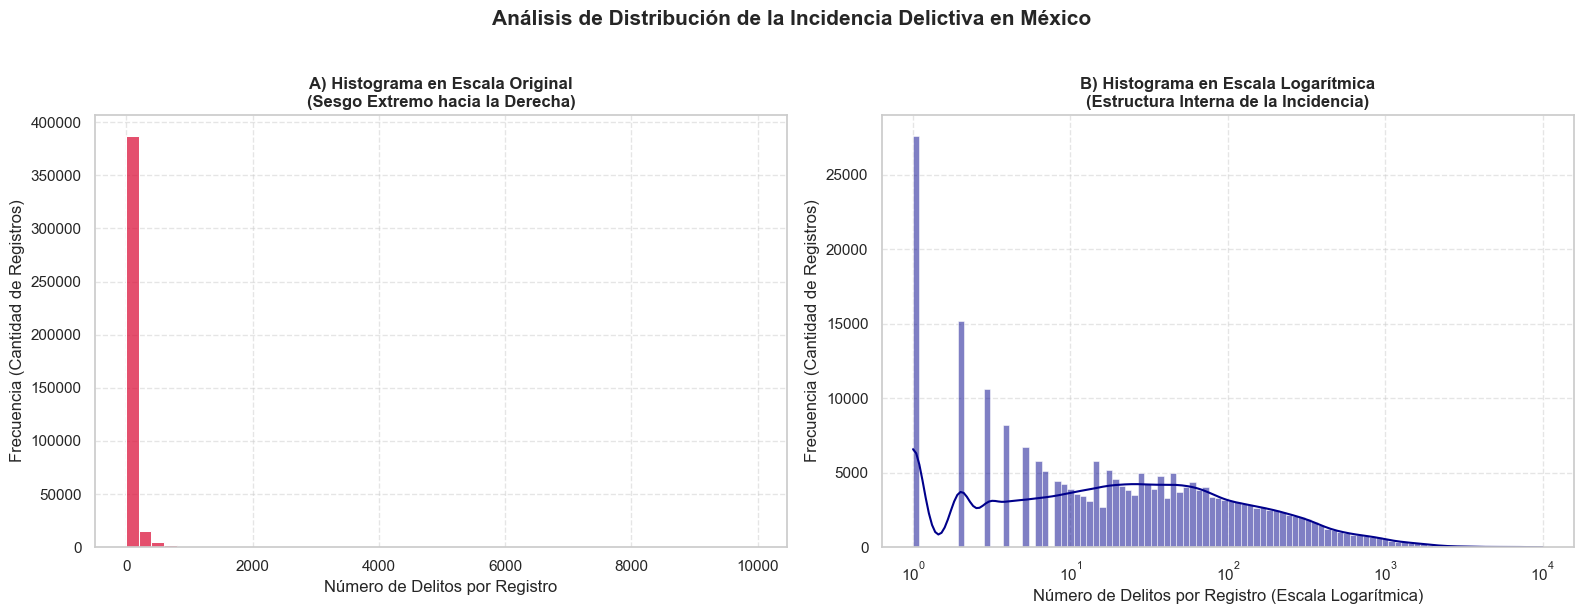

In [50]:
# Crear figura con 2 subgráficas lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(
    data=dataframe,
    x="incidencia_delictiva",
    bins=50,
    color="crimson",
    ax=axes[0]
)
axes[0].set_title("A) Histograma en Escala Original\n(Sesgo Extremo hacia la Derecha)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Número de Delitos por Registro")
axes[0].set_ylabel("Frecuencia (Cantidad de Registros)")
axes[0].grid(True, linestyle="--", alpha=0.5)

df_non_zero = dataframe[dataframe["incidencia_delictiva"] > 0]
sns.histplot(
    data=df_non_zero,
    x="incidencia_delictiva",
    kde=True,
    log_scale=True,
    color="darkblue",
    ax=axes[1]
)
axes[1].set_title("B) Histograma en Escala Logarítmica\n(Estructura Interna de la Incidencia)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Número de Delitos por Registro (Escala Logarítmica)")
axes[1].set_ylabel("Frecuencia (Cantidad de Registros)")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.suptitle("Análisis de Distribución de la Incidencia Delictiva en México", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

El primer gráfico muestra que una distribución con un sesgo hacia la derecha extremadamente severo. La inmensa mayoría de los registros del dataset se concentran de forma masiva en valores muy cercanos a cero (recordemos que la mediana del dataset es de 2 delitos por registro). Esto se debe a que existen muchas categorías de delitos poco comunes o entidades con menor población que reportan frecuentemente cero u muy pocas incidencias mensuales. Visualmente, esto genera una gran "pared" en el extremo izquierdo y una cola invisible infinitamente larga hacia la derecha que se extiende hasta el valor máximo de 9,968.

Con el segundo gráfico queremos reevelar la distribución real que queda oculta bajo el sesgo. Para esto se aplicó una escala logarítmica sobre el eje de las abscisas (filtrando los registros con $0$ delitos). Esto nos da distribución con dos picos:
- El primero muestra cuando se registran de 1 a 3 delitos en promedio. Esto representa la gran masa de reportes delictivos de baja ocurrencia o zonas con baja densidad demográfica.
- El segundo muestra cuando se registran de 30 a 100 delitos en promedio. Esto representa la acumulación de delitos altamente recurrentes (como variantes de robos) en zonas urbanas o de alta incidencia.

## Estadísticas Descriptivas Categóricas

In [10]:
stats.categorical_stats()

,columna,valores únicos,moda,frecuencia modal
0,fecha,132,2015-04-01,3136
1,entidad,32,Aguascalientes,12936
2,bien_juridico_afectado,7,El patrimonio,177408
3,tipo_delito,40,Robo,152064
4,subtipo_delito,55,Robo de maquinaria,25344
5,modalidad,59,Con violencia,50688


En cuanto a las variables categóricas del conjunto de datos podemos notar hechos bastante interesantes a pesar de la inmensidad del dataset:
- El dataset es de 11 años, sin embargo, solo hay 132 fechas únicas, con la fecha inicial siendo el 01 de enero de 2015
- La moda del dataset tiene algunos resultados curiosos. Este conjunto de datos es simetrico para cada estado, ya que existen 12936 líneas para c/u. Entonces, al querer cálcular la moda se toma el valor inicial de manera alfabética y resulta ser Aguascalientes. Sin embargo, esto no significa que sea la entidad con mayor apariciones del dataset.
- Lo anterior pasa de igual manera con la fecha, ya que toma la primera fecha del dataset para calcular este valor.
- El dataset reporta 40 tipos de delitos únicos reportados, con Robo siendo la categoría principal.

Veamos ahora un análisis más detallado de las variables categóricas.

### Delitos más comúnes

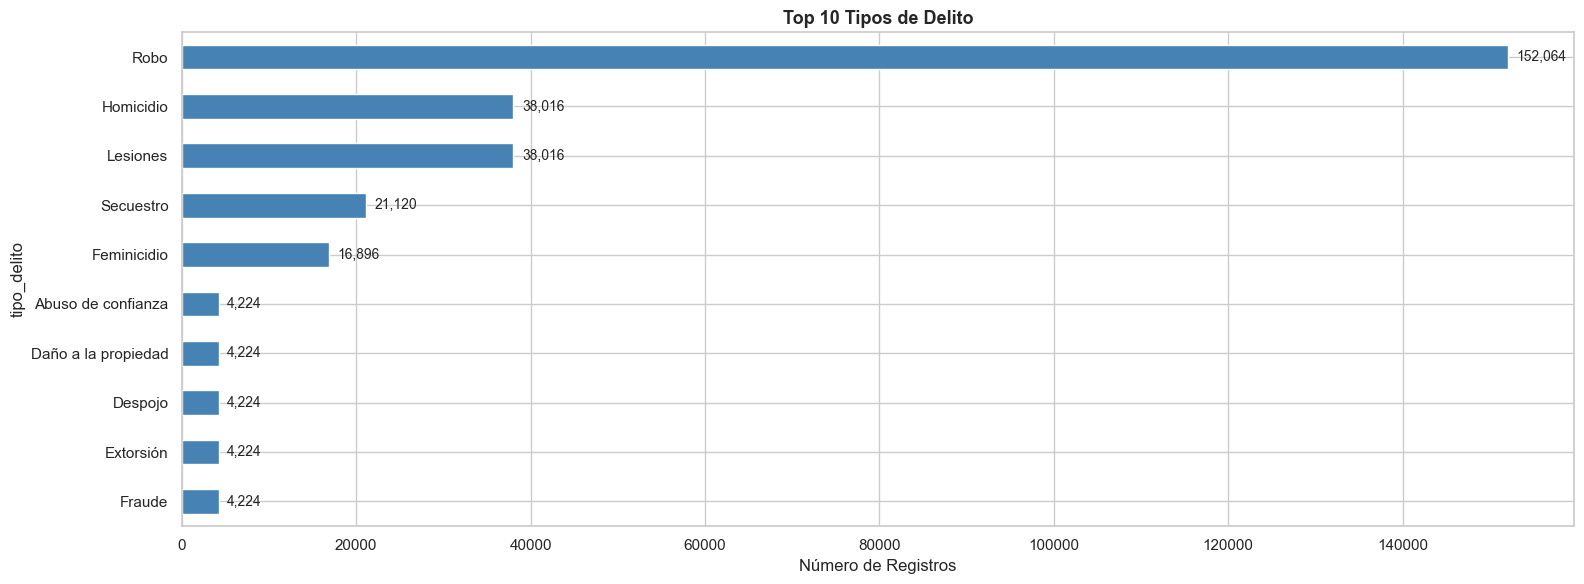

In [11]:
crime_counts = dataframe["tipo_delito"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(16, 6))
crime_counts.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 10 Tipos de Delito", fontsize=13, fontweight="bold")
ax.set_xlabel("Número de Registros")
ax.invert_yaxis()

# Añade valores en las barras
for i, v in enumerate(crime_counts.values):
    ax.text(v + 1000, i, f"{v:,}", va="center", fontsize=10)

plt.tight_layout()
plt.show()

Como se mencionaba en la tabla anterior, Robo es el delito más reportado, seguido de homicidio y lesiones. Algo a recordar es que aunque los feminicidios son también homicidios éstos están en una categoriá separada debido al motivo por el que ocurren. Vemos también que hay una extraña coincidencia de valores entre Abuso de Confianza, Daño a la Propiedad, Despojo, Extorsión y Fraude, lo que sugiere un sesgo al momento de reportar estos delitos por parte de la autoridad (por ejemplo, cifras redondeadas, reportes nulos, etc.)

### Incidencia Delictiva por Estado

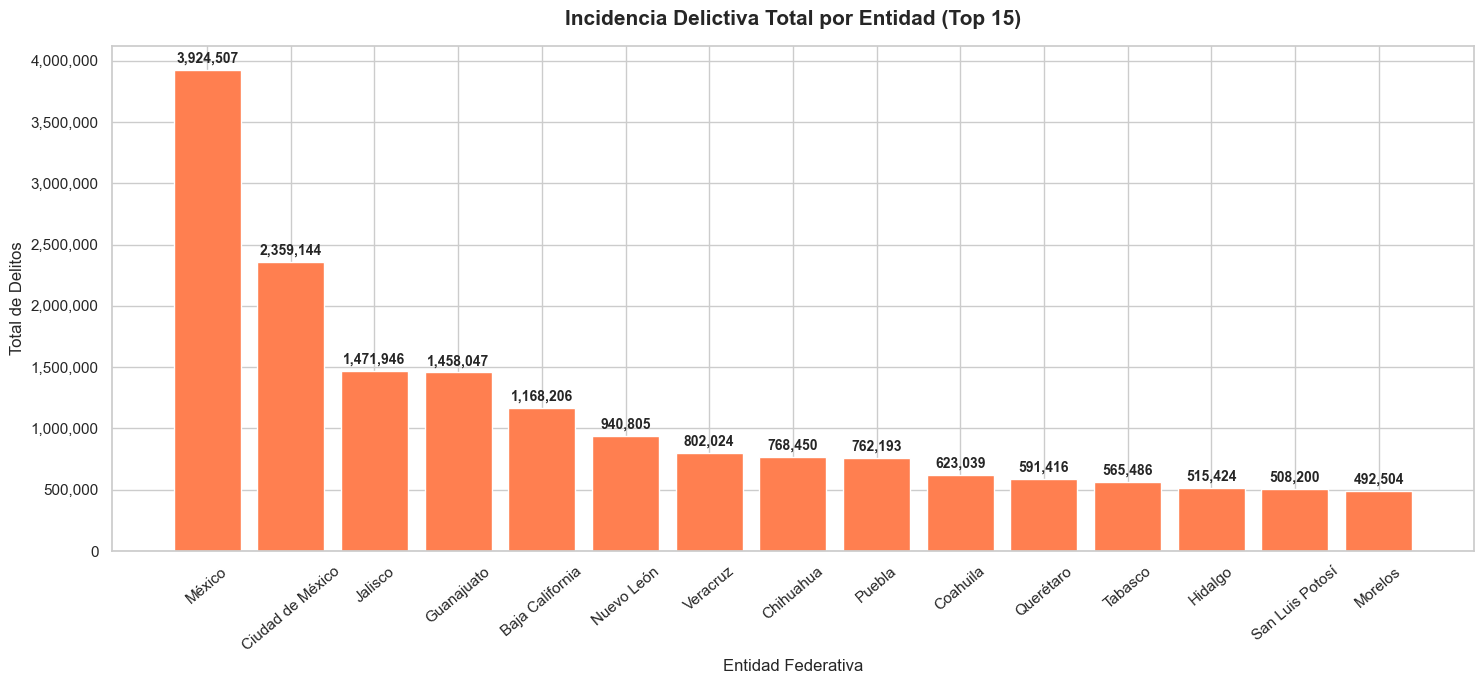

In [28]:
from matplotlib.ticker import StrMethodFormatter

entidad_counts = (
    dataframe.groupby("entidad")["incidencia_delictiva"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(15, 7))
bars = ax.bar(entidad_counts.index, entidad_counts.values, color="coral")
# Formato del eje Y con separadores de miles y sin decimales
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
# Agregamos los valores reales arriba de cada barra con separadores de miles
ax.bar_label(bars, fmt="{:,.0f}", padding=3, fontsize=10, fontweight="bold")

ax.set_title(
    "Incidencia Delictiva Total por Entidad (Top 15)",
    fontsize=15,
    fontweight="bold",
    pad=15,
)
ax.set_ylabel("Total de Delitos", fontsize=12)
ax.set_xlabel("Entidad Federativa", fontsize=12)
ax.tick_params(axis="x", rotation=40)

plt.tight_layout()
plt.show()

Nuestra sospecha anterior que la EdoMex y la CDMX son los estados con más reportes es correcta. Vemos que le siguen Jalisco, Guanajuato y Baja California y que, a pesar de la moda, 
Aguascalientes no figura dentro de los estados con más delitos reportados.

Veamos ahora la relación estado-delito:

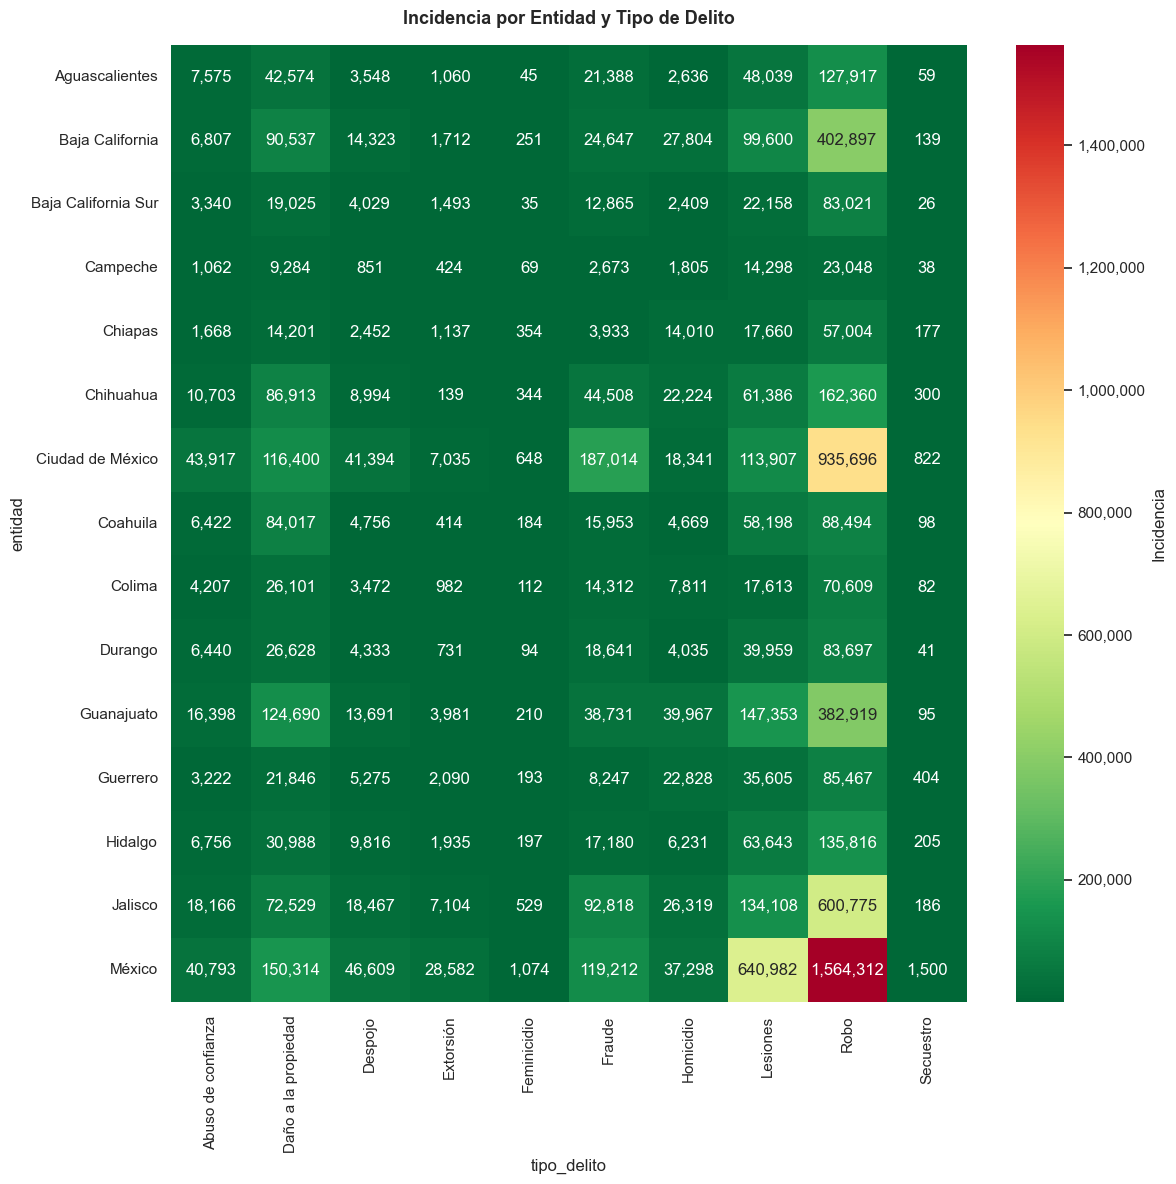

In [37]:
top_crimes = dataframe["tipo_delito"].value_counts().head(10).index
top_entities = dataframe["entidad"].value_counts().head(15).index

filtered_df = dataframe[dataframe["tipo_delito"].isin(top_crimes) & dataframe["entidad"].isin(top_entities)]

pivot = filtered_df.pivot_table(
    values="incidencia_delictiva", index="entidad", columns="tipo_delito", aggfunc="sum"
)

fig, ax = plt.subplots(figsize=(12, 12))
sns.heatmap(
    pivot,
    cmap="RdYlGn_r",
    annot=True,
    fmt=",.0f",  # Agregamos la coma para que los números dentro del mapa tengan comas (ej. 1,234,567)
    cbar_kws={"label": "Incidencia"},
    ax=ax,
)

cbar = ax.collections[0].colorbar
# aplicamos formato con comas de miles y sin decimales
cbar.ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

ax.set_title(
    "Incidencia por Entidad y Tipo de Delito",
    fontsize=13,
    fontweight="bold",
    pad=15
)

plt.tight_layout()
plt.show()

### Bienes Jurídicos Afectados

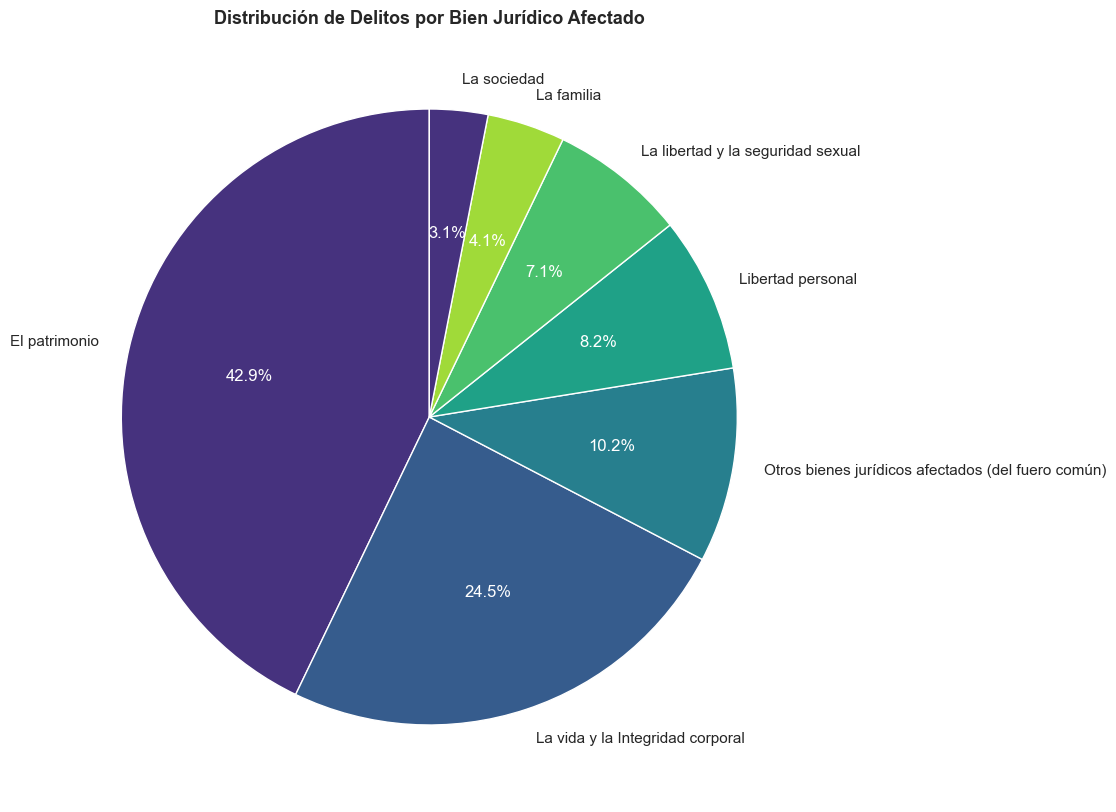

In [13]:
bien_juridico = dataframe["bien_juridico_afectado"].value_counts()

fig, ax = plt.subplots(figsize=(10, 10))
wedges, texts, autotexts = ax.pie(
    bien_juridico.values, labels=bien_juridico.index, autopct="%1.1f%%", startangle=90
)
ax.set_title(
    "Distribución de Delitos por Bien Jurídico Afectado", fontsize=13, fontweight="bold"
)
for autotext in autotexts:
    autotext.set_color("white")

plt.show()

Para entender esta gráfica debemos entender que la ley define como 'bienes jurídicos' a aquellos objetos o relaciones, tangibles o intangibles, que cuentan con la protección de la ley, como un inmueble, la vida, dinero, etc. En particular, debemos entender que 'El patrimonio' hace referencia al conjunto de bienes, derechos y obligaciones de una persona, susceptibles de valoración económica. Lo anterior, en otros términos, se refiere a pertenencias que hemos comprado, dinero que tenga un individuo, etc, pero que tengan relevancia ecónomica. 

Ahora pues, tomando en cuenta de que el delito más reportado es el robo, que el patrimonio sea el bien más afectado tiene mucho sentido. Luego, al ser el homicidio, lesiones, secuestro y feminicidio los delitos que siguen en frecuencia, hace nuevamente sentido que la vida e integridad corportal sean el segundo bien más afectado.

### Modalidad del Delito

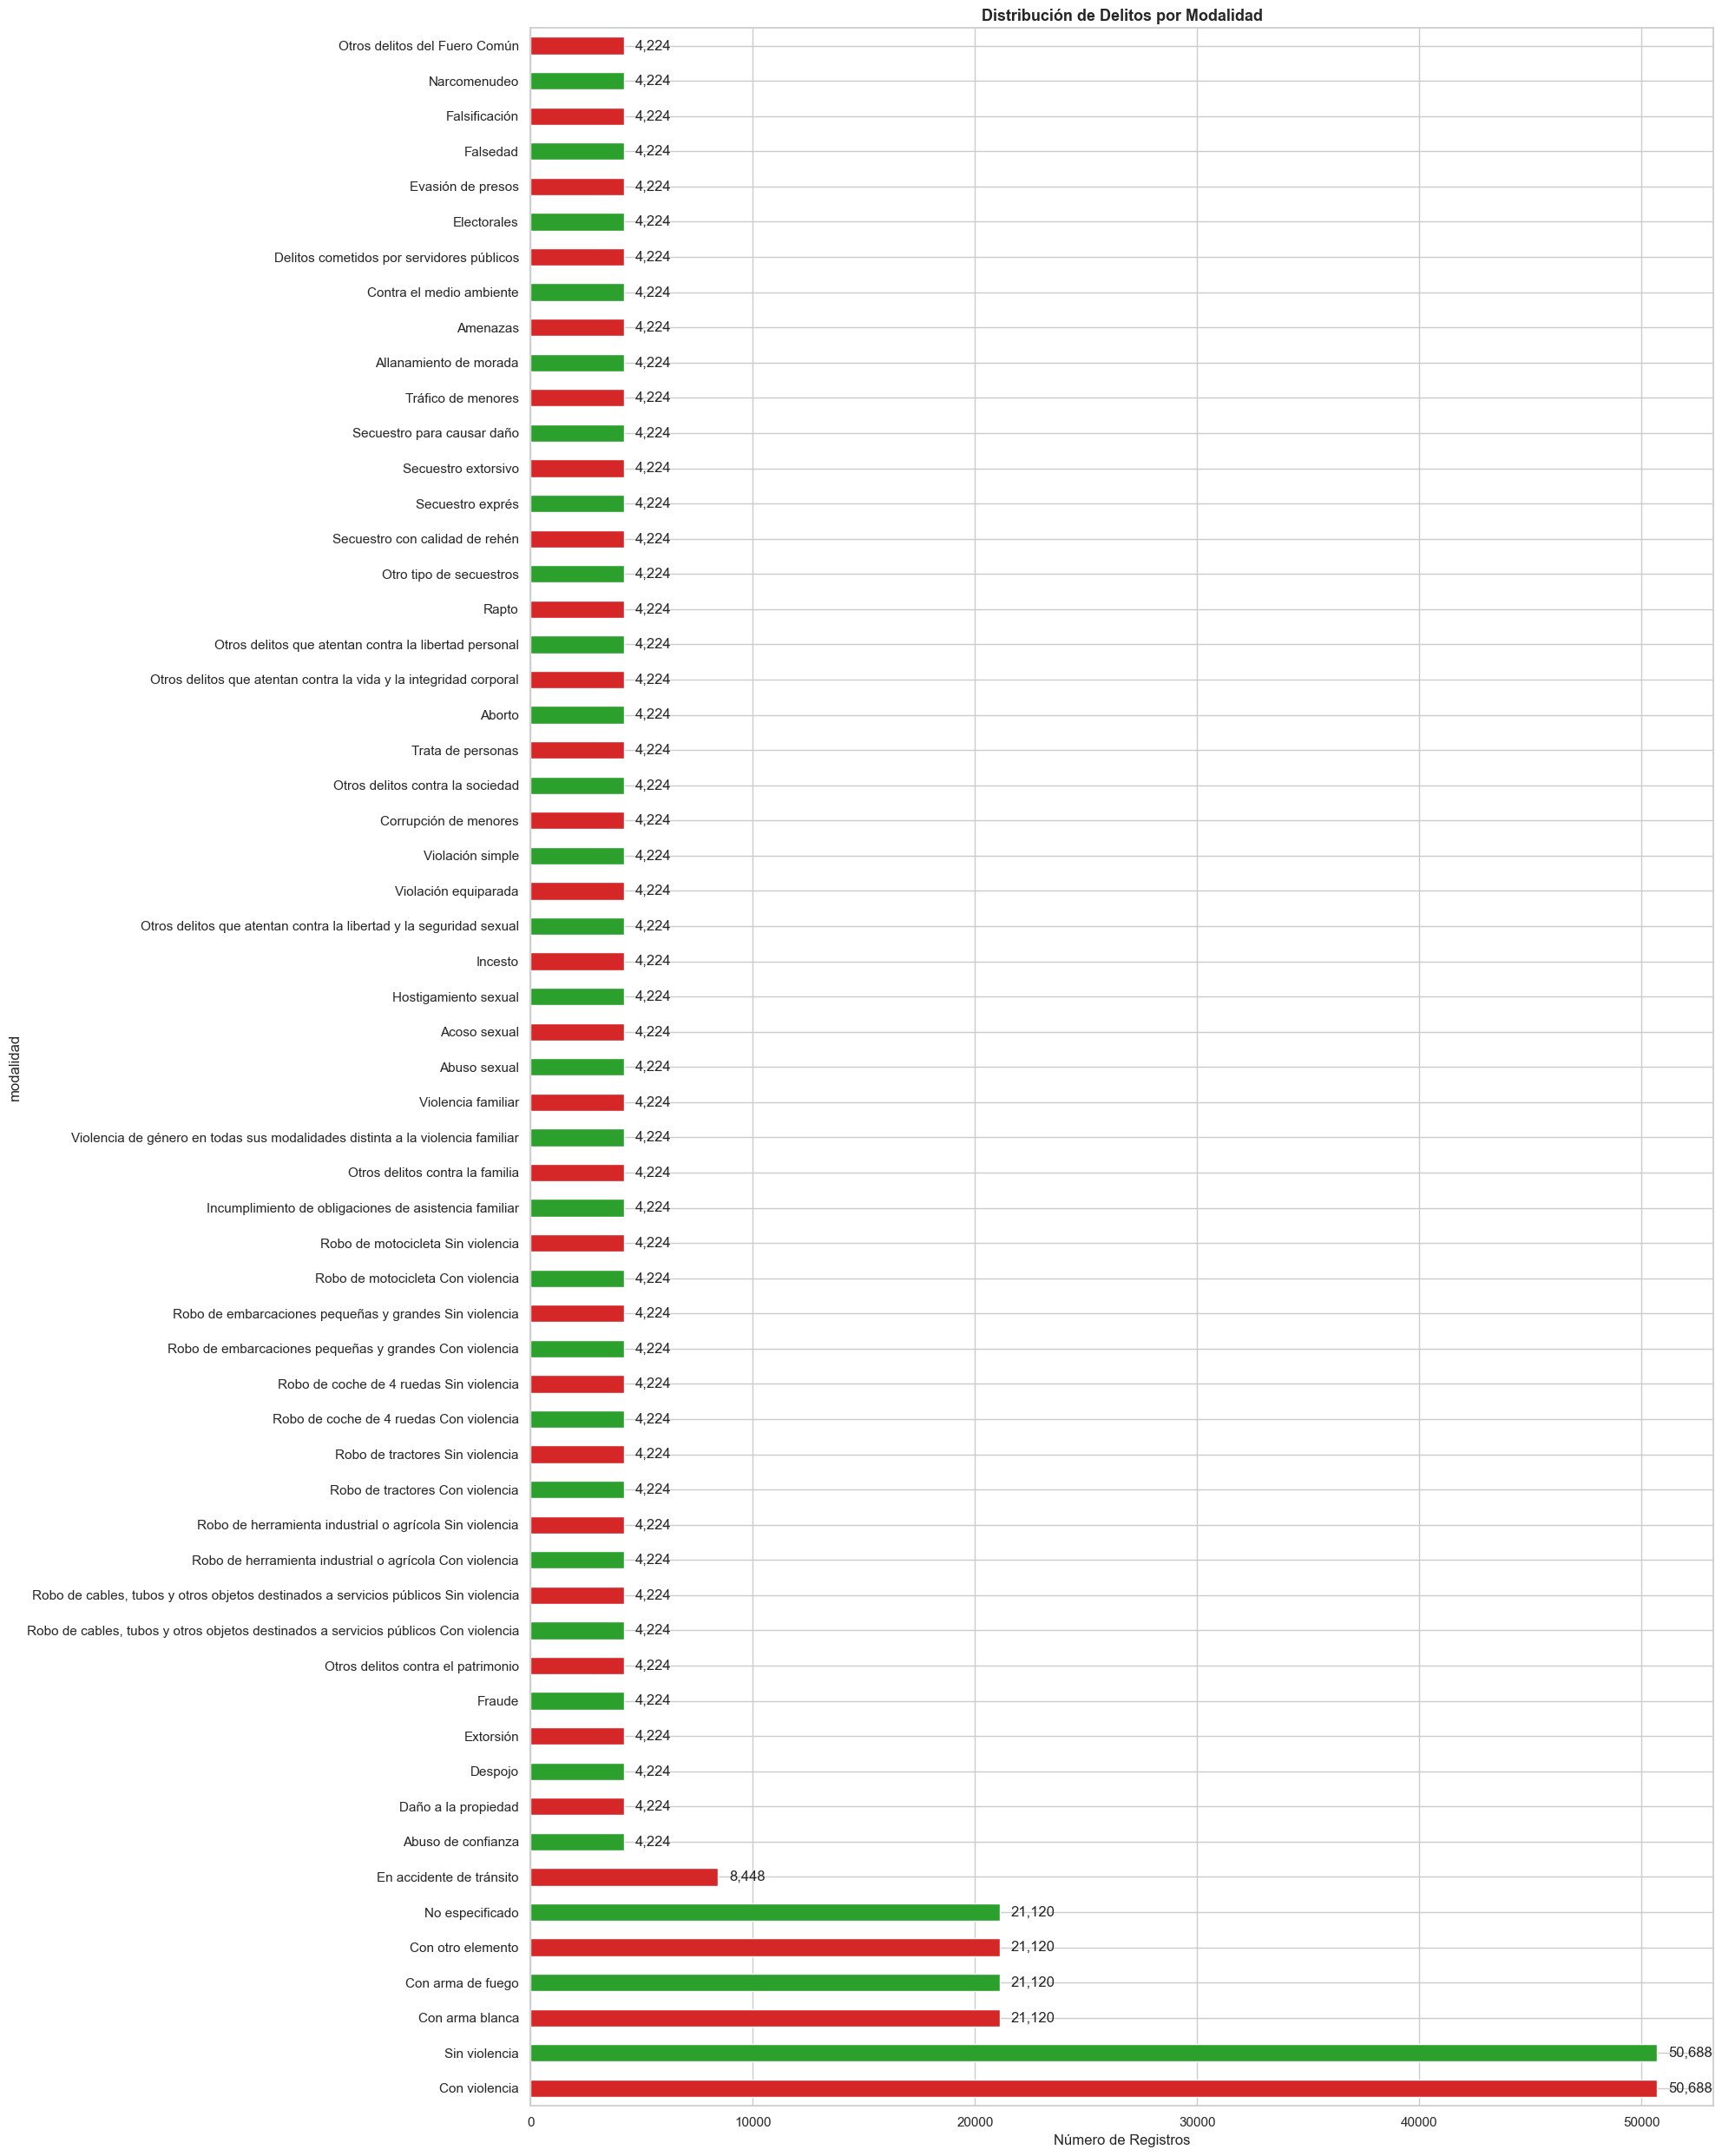

In [18]:
modalidad = dataframe["modalidad"].value_counts()

fig, ax = plt.subplots(figsize=(20, 25))
modalidad.plot(kind="barh", ax=ax, color=["#d62728", "#2ca02c"])

ax.set_title("Distribución de Delitos por Modalidad", fontsize=13, fontweight="bold")
ax.set_xlabel("Número de Registros")

for i, v in enumerate(modalidad.values):
    ax.text(v + 500, i, f"{v:,}", va="center")

plt.tight_layout()
plt.show()

Nuevamente, vemos también que hay una extranña coincidencia de valores después de la modalidad 'En Accidente de Tráfico', lo que sugiere y mantiene la idea de que existe un gran sesgo al momento de
reportar correctamente todos los delitos. 

También notamos que no existe una única forma de reportar los delitos con violencia, por lo que un registro puede pertenecer a un delito con ésta modalidad y ser asignado a otra categoria (sobre todo en lo referente a los subtipos de robo).

### Delincuencia por Año

Veamos la evolución de los delitos a lo largo del tiempo del dataset (2015-2025)

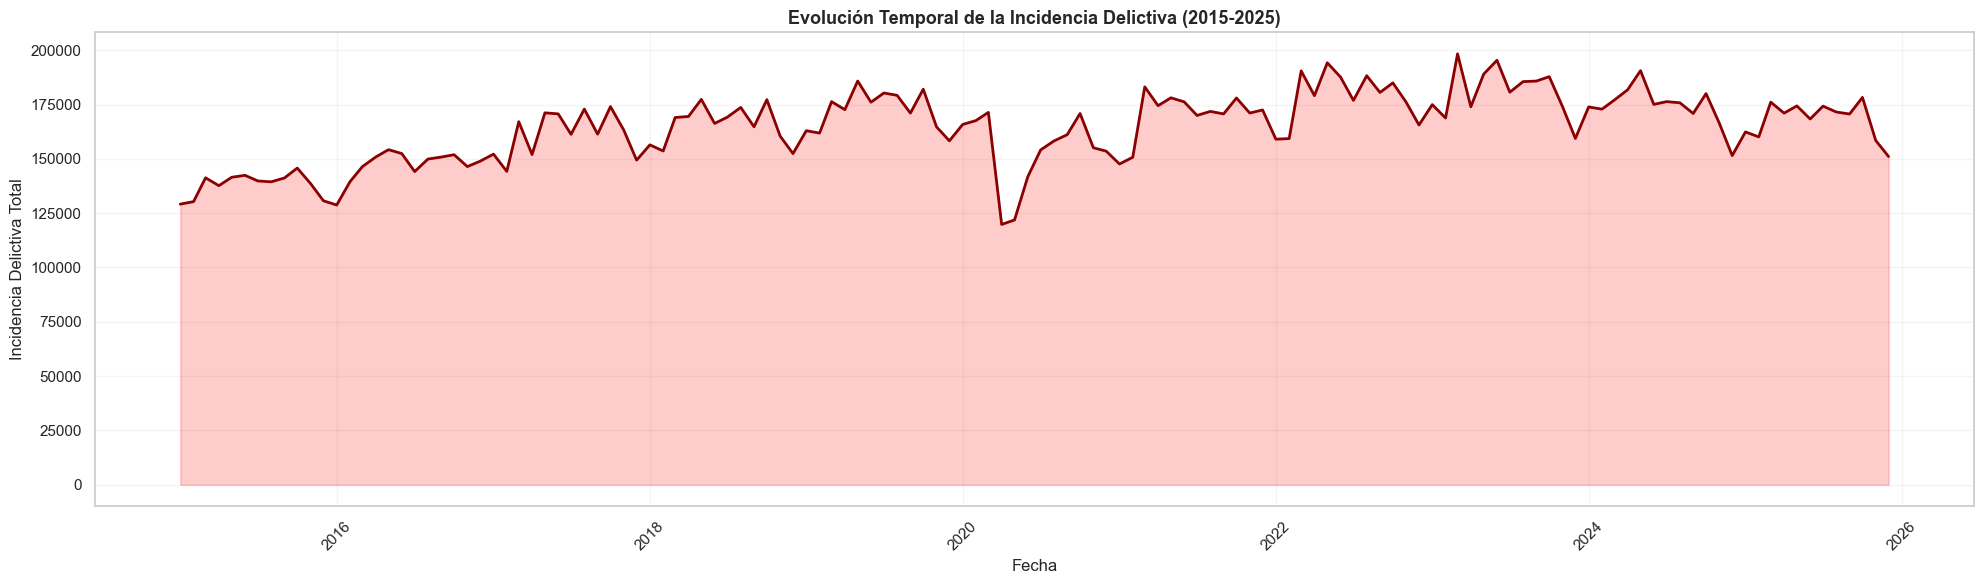

In [43]:
temporal = dataframe.groupby("fecha")["incidencia_delictiva"].sum().sort_index()

fig, ax = plt.subplots(figsize=(20, 6))
ax.plot(temporal.index, temporal.values, linewidth=2, color="darkred")
ax.fill_between(temporal.index, temporal.values, alpha=0.2, color="red")

ax.set_title(
    "Evolución Temporal de la Incidencia Delictiva (2015-2025)",
    fontsize=13,
    fontweight="bold",
)
ax.set_xlabel("Fecha")
ax.set_ylabel("Incidencia Delictiva Total")
ax.grid(True, alpha=0.2)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Vemos que, desafortunadamente, no existe un decrecimiento notable en cuanto a la delicuencia en este periodo de tiempo. E incluso, desde 2022 hacia adelante es donde se alcanzan
números más alto. 

Veamos ahora como se ve ésta evolución dados los meses del año:

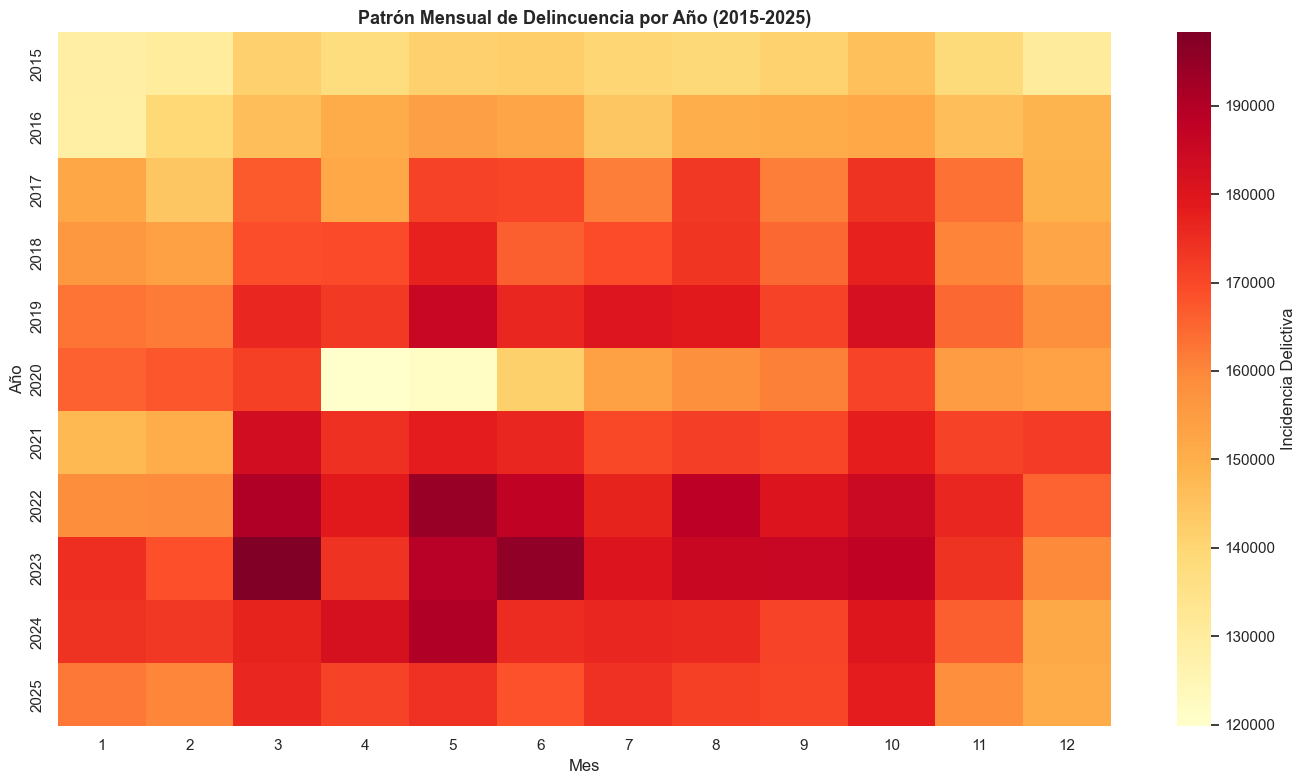

In [17]:
dataframe["fecha"] = pd.to_datetime(dataframe["fecha"])
dataframe["año"] = dataframe["fecha"].dt.year
dataframe["mes"] = dataframe["fecha"].dt.month

pivot_data = dataframe.groupby(["año", "mes"])["incidencia_delictiva"].sum().unstack()

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    pivot_data,
    cmap="YlOrRd",
    annot=False,
    fmt="d",
    cbar_kws={"label": "Incidencia Delictiva"},
    ax=ax,
)

ax.set_title(
    "Patrón Mensual de Delincuencia por Año (2015-2025)", fontsize=13, fontweight="bold"
)
ax.set_xlabel("Mes")
ax.set_ylabel("Año")

plt.tight_layout()
plt.show()

Vemos que en particular, de 2021 a 2025 el foco ha sido entre Marzo a Junio. Mientras que en años anteriores habia sido de Mayo a Agosto (2015-2019). Lo que si es más fácil de notar con esto es que 2020 tiene los valores más bajos de todos los años del conjunto, lo que puede deberse a que la incidencia delicitiva realmente bajó durante ese periodo o que directamente no se reportó por completo.

## Detección de Valores Atípicos

Para detectar outliers lo que haremos será ocupar IQR. Por lo anterior notamos que la incidencia delictiva está fuertemente sesgada a la derecha por la CDMX y Edomex, ya que disparan los valores frente a estados pequeños. El z-score asume normalidad y los propios extremos inflan media y desviación, así que ocupar ésta medida reportaría resultados sesgados. 

Luego, en luga de eliminar estos valores directamente, lo que haremos será identificarlos y añadir una columna extra en donde se indique si son o no outliers. Esto por que estos registros atípicos no son inicialmente errores de captura si no señales reales de la delincuencia en el país, y eliminar estos valores distorsionaría el análisis. 

Para esto lo que haremos será ocupar la clase `OutlierDetector` que, como su nombre lo indica, identificará los valores atípicos y luego usaremos su método `flag()` para aplicar ésta identificación a un nuevo dataframe.

In [14]:
det = OutlierDetector(dataframe, columns=["incidencia_delictiva"])
det.summary()

,columna,n_total,min,max,lower,upper,n_outliers,pct_outliers
0,incidencia_delictiva,413952,0.0,9968.0,-39.0,65.0,63128,15.250077


In [15]:
det.flag()

,fecha,entidad,bien_juridico_afectado,tipo_delito,subtipo_delito,modalidad,incidencia_delictiva,incidencia_delictiva_is_outlier
0,2015-04-01,Aguascalientes,El patrimonio,Abuso de confianza,Abuso de confianza,Abuso de confianza,22,False
1,2015-08-01,Aguascalientes,El patrimonio,Abuso de confianza,Abuso de confianza,Abuso de confianza,40,False
2,2015-12-01,Aguascalientes,El patrimonio,Abuso de confianza,Abuso de confianza,Abuso de confianza,26,False
3,2015-01-01,Aguascalientes,El patrimonio,Abuso de confianza,Abuso de confianza,Abuso de confianza,41,False
4,2015-02-01,Aguascalientes,El patrimonio,Abuso de confianza,Abuso de confianza,Abuso de confianza,33,False
...,...,...,...,...,...,...,...,...
413947,2025-03-01,Zacatecas,Otros bienes jurídicos afectados (del fuero común),Otros delitos del Fuero Común,Otros delitos del Fuero Común,Otros delitos del Fuero Común,184,True
413948,2025-05-01,Zacatecas,Otros bienes jurídicos afectados (del fuero común),Otros delitos del Fuero Común,Otros delitos del Fuero Común,Otros delitos del Fuero Común,98,True
413949,2025-11-01,Zacatecas,Otros bienes jurídicos afectados (del fuero común),Otros delitos del Fuero Común,Otros delitos del Fuero Común,Otros delitos del Fuero Común,92,True
413950,2025-10-01,Zacatecas,Otros bienes jurídicos afectados (del fuero común),Otros delitos del Fuero Común,Otros delitos del Fuero Común,Otros delitos del Fuero Común,99,True
